# Assignment 4
COMP 6630 - Clay Ramey

In [2]:
import pandas as pd
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

# load data
df_train = pd.read_excel('Asssignment4_Data.xlsx', sheet_name='Train')
df_test  = pd.read_excel('Asssignment4_Data.xlsx', sheet_name='Test')

feature_cols = ['Local Price', 'Bathrooms', 'Land Area', 'Living area',
                '# Garages', '# Rooms', '# Bedrooms', 'Age of home']
target_col = 'Construction type'
classes    = ['Apartment', 'House', 'Condo']

X_train = df_train[feature_cols]
y_train = df_train[target_col]
X_test  = df_test[feature_cols]
y_test  = df_test[target_col]

print('training set:')
display(df_train)
print('test set:')
display(df_test)

training set:


,House ID,Local Price,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Construction type
0,1,4.9176,1.0,3.4720,0.998,1.0,7,4,42,Apartment
1,2,5.0208,1.0,3.5310,1.500,2.0,7,4,62,House
2,3,4.5429,1.0,2.2750,1.175,1.0,6,3,40,Condo
3,4,4.5573,1.0,4.0500,1.232,1.0,6,3,54,Apartment
4,5,5.0597,1.0,4.4550,1.121,1.0,6,3,42,Apartment
5,6,3.8910,1.0,4.4550,0.988,1.0,6,3,56,Condo
6,7,5.8980,1.0,5.8500,1.240,1.0,7,3,51,Condo
7,8,5.6039,1.0,9.5200,1.501,0.0,6,3,32,House
8,9,16.4202,2.5,9.8000,3.420,2.0,10,5,42,Condo
9,10,14.4598,2.5,12.8000,3.000,2.0,9,5,14,Apartment


test set:


,House ID,Local Price,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Construction type
0,24,6.0931,1.5,6.7265,1.652,1.0,6,3,44,Apartment
1,25,8.3607,1.5,9.1500,1.777,2.0,8,4,48,House
2,26,8.1400,1.0,8.0000,1.504,2.0,7,3,3,House
3,27,9.1416,1.5,7.3262,1.831,1.5,8,4,31,Apartment
4,28,12.0000,1.5,5.0000,1.200,2.0,6,3,30,Apartment


## Section 1 Naive Bayes

### 1.1 Conditional Probability Distributions

The target variable is Construction type which has 3 classes: Apartment, House, Condo. All 8 features are continuous numbers so I used Gaussian Naive Bayes. For each feature and each class I need the mean and standard deviation. Then I can plug values into the Gaussian formula to get P(feature | class).

The formula is:

P(x | c) = (1 / (std * sqrt(2 * pi))) * exp(-(x - mean)^2 / (2 * std^2))

Step 1 - count how many of each class are in the training set to get the prior probabilities.

Apartment: 7 out of 20 = 0.35
House: 7 out of 20 = 0.35
Condo: 6 out of 20 = 0.30

Step 2 - for each feature, compute the mean and std for each class using only the training rows that belong to that class.

In [3]:
# compute priors
counts  = {c: (y_train == c).sum() for c in classes}
n_total = len(y_train)
priors  = {c: counts[c] / n_total for c in classes}

print('prior probabilities:')
for c in classes:
    print(f'  p({c}) = {counts[c]}/{n_total} = {priors[c]:.4f}')

# compute mean and std per class per feature
cond = {}
for c in classes:
    X_c = X_train[y_train == c]
    cond[c] = {'mean': X_c.mean(), 'std': X_c.std(ddof=0)}

# build summary table
rows = []
for f in feature_cols:
    row = {'feature': f}
    for c in classes:
        row[f'{c} mean'] = round(cond[c]['mean'][f], 4)
        row[f'{c} std']  = round(cond[c]['std'][f],  4)
    rows.append(row)

print('\nconditional probability parameters (mean, std) per class:')
display(pd.DataFrame(rows).set_index('feature'))

prior probabilities:
  p(Apartment) = 7/20 = 0.3500
  p(House) = 7/20 = 0.3500
  p(Condo) = 6/20 = 0.3000

conditional probability parameters (mean, std) per class:


,Apartment mean,Apartment std,House mean,House std,Condo mean,Condo std
feature,,,,,,
Local Price,7.3327,3.3478,5.7607,0.5278,7.4159,4.2095
Bathrooms,1.2857,0.5249,1.0714,0.1750,1.3333,0.5528
Land Area,6.1039,3.0168,6.6309,2.0821,6.0247,2.3231
Living area,1.5050,0.6519,1.3917,0.1971,1.5533,0.8430
# Garages,1.2143,0.6468,1.0714,0.7759,1.3333,0.4714
# Rooms,6.8571,1.2454,6.1429,0.6389,6.8333,1.4625
# Bedrooms,3.4286,0.9035,3.0000,0.5345,3.3333,0.7454
Age of home,38.7143,13.5932,34.2857,11.7803,39.6667,12.7366


### Feature 1 worked example: Local Price

I pulled the Local Price values for each class from the training data.

Apartment (house IDs 1,4,5,10,15,17,20): 4.9176, 4.5573, 5.0597, 14.4598, 5.05, 8.2464, 9.0384
House (house IDs 2,8,11,12,13,16,18): 5.0208, 5.6039, 5.8282, 5.3003, 6.2712, 5.6039, 6.6969
Condo (house IDs 3,6,7,9,14,19): 4.5429, 3.891, 5.898, 16.4202, 5.9592, 7.7841

For Apartment, add all 7 values and divide by 7:

mean = (4.9176 + 4.5573 + 5.0597 + 14.4598 + 5.05 + 8.2464 + 9.0384) / 7 = 51.3292 / 7 = 7.3327

Then for std, take each value minus the mean, square it, average all of them, then square root:

std = sqrt(((4.9176-7.3327)^2 + (4.5573-7.3327)^2 + (5.0597-7.3327)^2 + (14.4598-7.3327)^2 + (5.05-7.3327)^2 + (8.2464-7.3327)^2 + (9.0384-7.3327)^2) / 7) = sqrt(74.946 / 7) = sqrt(10.706) = 3.3478

For House:

mean = (5.0208 + 5.6039 + 5.8282 + 5.3003 + 6.2712 + 5.6039 + 6.6969) / 7 = 40.3252 / 7 = 5.7607
std = 0.5278

For Condo:

mean = (4.5429 + 3.891 + 5.898 + 16.4202 + 5.9592 + 7.7841) / 6 = 44.4954 / 6 = 7.4159
std = 4.2095

### Feature 2 worked example: Age of Home

Apartment ages: 42, 54, 42, 14, 46, 50, 23
House ages: 62, 32, 32, 30, 30, 32, 22
Condo ages: 40, 56, 51, 42, 32, 17

For Apartment:

mean = (42 + 54 + 42 + 14 + 46 + 50 + 23) / 7 = 271 / 7 = 38.7143
std = 13.5932

For House:

mean = (62 + 32 + 32 + 30 + 30 + 32 + 22) / 7 = 240 / 7 = 34.2857
std = 11.7803

For Condo:

mean = (40 + 56 + 51 + 42 + 32 + 17) / 6 = 238 / 6 = 39.6667
std = 12.7366

Houses tend to be a bit newer on average (mean age 34.3) compared to apartments (38.7) and condos (39.7). The means are close though so age alone wont perfectly separate the classes.

### 1.2 Python Code with Hard-coded Probabilities

Below I hard-coded all the means and stds from the table above. For each test instance I compute the MAP class using: predicted class = argmax over c of P(c) * product of P(xi | c) for all features.

In [5]:
# hard-coded priors
PRIORS = {
    'Apartment': 7 / 20,
    'House':     7 / 20,
    'Condo':     6 / 20,
}

# hard-coded gaussian parameters (mean, std) from section 1.1
PARAMS = {
    'Apartment': {
        'Local Price':  (7.3327,  3.3478),
        'Bathrooms':    (1.2857,  0.5249),
        'Land Area':    (6.1039,  3.0168),
        'Living area':  (1.5050,  0.6519),
        '# Garages':    (1.2143,  0.6468),
        '# Rooms':      (6.8571,  1.2454),
        '# Bedrooms':   (3.4286,  0.9035),
        'Age of home':  (38.7143, 13.5932),
    },
    'House': {
        'Local Price':  (5.7607,  0.5278),
        'Bathrooms':    (1.0714,  0.1750),
        'Land Area':    (6.6309,  2.0821),
        'Living area':  (1.3917,  0.1971),
        '# Garages':    (1.0714,  0.7759),
        '# Rooms':      (6.1429,  0.6389),
        '# Bedrooms':   (3.0000,  0.5345),
        'Age of home':  (34.2857, 11.7803),
    },
    'Condo': {
        'Local Price':  (7.4159,  4.2095),
        'Bathrooms':    (1.3333,  0.5528),
        'Land Area':    (6.0247,  2.3231),
        'Living area':  (1.5533,  0.8430),
        '# Garages':    (1.3333,  0.4714),
        '# Rooms':      (6.8333,  1.4625),
        '# Bedrooms':   (3.3333,  0.7454),
        'Age of home':  (39.6667, 12.7366),
    },
}


def gaussian_pdf(x, mu, sigma):
    # returns gaussian likelihood for a single value
    if sigma == 0:
        return 1.0 if x == mu else 1e-9
    return (1.0 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mu) / sigma) ** 2)


def predict(instance):
    # computes map class for one instance
    scores = {}
    for cls in PRIORS:
        score = PRIORS[cls]
        for f in feature_cols:
            mu, sigma = PARAMS[cls][f]
            score *= gaussian_pdf(instance[f], mu, sigma)
        scores[cls] = score

    total     = sum(scores.values())
    norm_probs = {cls: scores[cls] / total for cls in scores} if total > 0 else {cls: 1/3 for cls in scores}
    predicted  = max(scores, key=scores.get)
    return norm_probs, predicted


# run on test data
print('naive bayes predictions on test data')
print('-' * 50)

results = []
for _, row in df_test.iterrows():
    probs, predicted = predict(row)
    actual  = row[target_col]
    correct = (predicted == actual)

    print(f"\nhouse {int(row['House ID'])}:")
    for cls in PRIORS:
        print(f'  p({cls}) = {probs[cls]:.6f}')
    print(f'  predicted: {predicted}')
    print(f'  actual:    {actual}  ({"correct" if correct else "wrong"})')
    results.append({'House ID': int(row['House ID']), 'Predicted': predicted,
                    'Actual': actual, 'Correct': correct})

res_df   = pd.DataFrame(results)
accuracy = res_df['Correct'].mean()
print(f'\ntest accuracy: {res_df["Correct"].sum()}/{len(res_df)} = {accuracy:.2%}')

naive bayes predictions on test data
--------------------------------------------------

house 24:
  p(Apartment) = 0.115422
  p(House) = 0.775518
  p(Condo) = 0.109061
  predicted: House
  actual:    Apartment  (wrong)

house 25:
  p(Apartment) = 0.655056
  p(House) = 0.000000
  p(Condo) = 0.344944
  predicted: Apartment
  actual:    House  (wrong)

house 26:
  p(Apartment) = 0.756000
  p(House) = 0.003361
  p(Condo) = 0.240639
  predicted: Apartment
  actual:    House  (wrong)

house 27:
  p(Apartment) = 0.513623
  p(House) = 0.000000
  p(Condo) = 0.486377
  predicted: Apartment
  actual:    Apartment  (correct)

house 28:
  p(Apartment) = 0.466909
  p(House) = 0.000000
  p(Condo) = 0.533091
  predicted: Condo
  actual:    Apartment  (wrong)

test accuracy: 1/5 = 20.00%


---
## Section 2 - Decision Tree

In [6]:
from sklearn.tree import DecisionTreeClassifier, export_text
import matplotlib.pyplot as plt
from sklearn import tree as sk_tree

X_tr = df_train[feature_cols]
y_tr = df_train[target_col]
X_te = df_test[feature_cols]
y_te = df_test[target_col]

### 2.1 Default Parameters

In [7]:
# train with default settings
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_tr, y_tr)

train_acc = dt_default.score(X_tr, y_tr)
test_acc  = dt_default.score(X_te, y_te)

print(f'default tree depth: {dt_default.get_depth()}')
print(f'training accuracy:  {train_acc:.2%}')
print(f'test accuracy:      {test_acc:.2%}')

default tree depth: 5
training accuracy:  100.00%
test accuracy:      40.00%


a) Training accuracy is 100%. The tree has no depth limit so it keeps splitting until every leaf is pure, which means it perfectly fits all 20 training examples.

b) Test accuracy is 40%. The tree overfits the training data badly. It memorized all the training examples but that did not help on new data, so it only got 2 out of 5 test houses right.

### 2.2 Effect of Max Depth

,train_accuracy,test_accuracy
max_depth,,
1,0.55,0.4
2,0.75,0.8
3,0.90,0.4
4,0.95,0.4
5,1.00,0.4
6,1.00,0.4
7,1.00,0.4


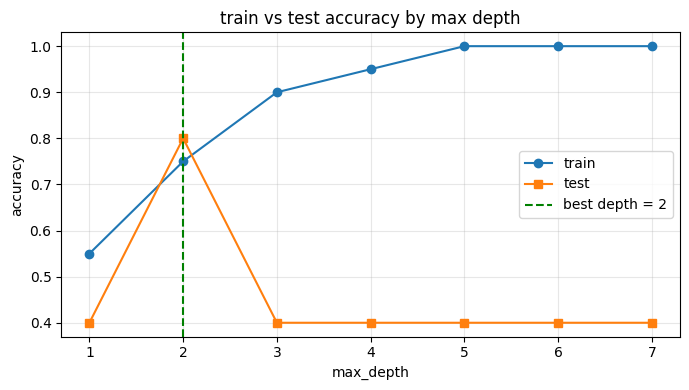

In [8]:
# try different max depths and record train/test accuracy
depth_results = []
for d in range(1, 8):
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_tr, y_tr)
    depth_results.append({
        'max_depth':      d,
        'train_accuracy': dt_d.score(X_tr, y_tr),
        'test_accuracy':  dt_d.score(X_te, y_te),
    })

dr_df = pd.DataFrame(depth_results)
display(dr_df.set_index('max_depth'))

# plot train vs test accuracy
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dr_df['max_depth'], dr_df['train_accuracy'], marker='o', label='train')
ax.plot(dr_df['max_depth'], dr_df['test_accuracy'],  marker='s', label='test')
ax.axvline(x=2, color='green', linestyle='--', label='best depth = 2')
ax.set_xlabel('max_depth')
ax.set_ylabel('accuracy')
ax.set_title('train vs test accuracy by max depth')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Limiting the max depth reduces overfitting. When depth is 1 the tree is too simple and only gets 55% on training. At depth 2 it gets 75% training and 80% test which is the best test accuracy. After depth 2 the training accuracy keeps going up but test accuracy drops back to 40%, meaning the tree is overfitting again. The best max depth is 2.

### 2.3 Rules from the Best Depth Tree (max_depth = 2)

In [9]:
# train the best tree
dt_best = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_best.fit(X_tr, y_tr)

print('tree structure:')
print(export_text(dt_best, feature_names=feature_cols))

tree structure:
|--- Age of home <= 36.00
|   |--- Local Price <= 8.41
|   |   |--- class: House
|   |--- Local Price >  8.41
|   |   |--- class: Apartment
|--- Age of home >  36.00
|   |--- Local Price <= 4.55
|   |   |--- class: Condo
|   |--- Local Price >  4.55
|   |   |--- class: Apartment



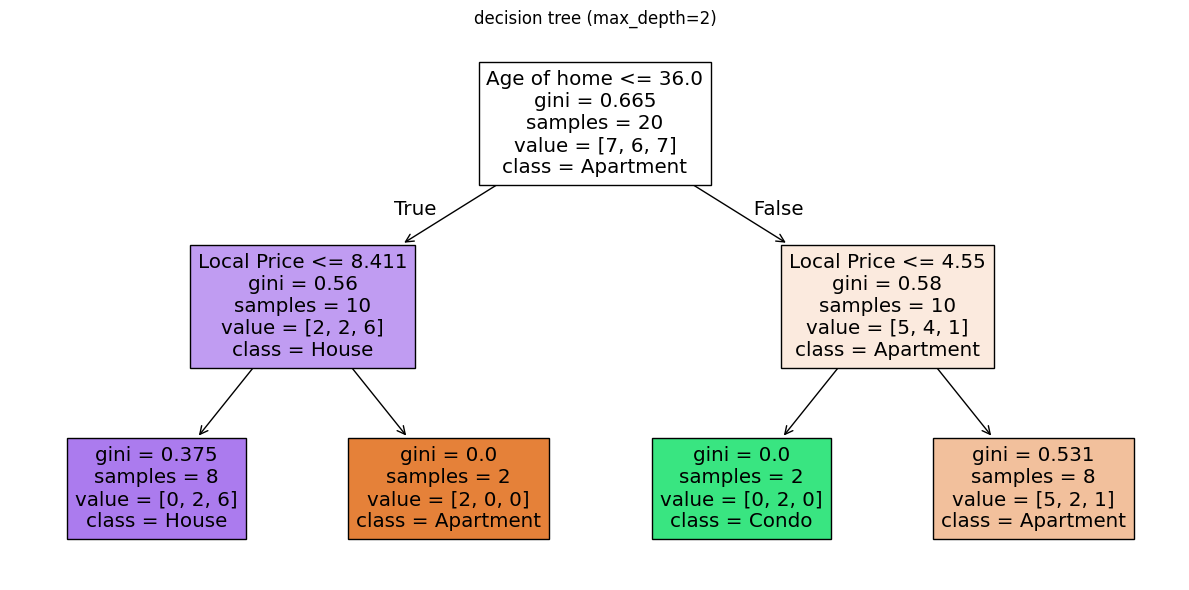

In [10]:
# visualize the tree
fig, ax = plt.subplots(figsize=(12, 6))
sk_tree.plot_tree(dt_best, feature_names=feature_cols,
                  class_names=dt_best.classes_, filled=True, ax=ax)
plt.title('decision tree (max_depth=2)')
plt.tight_layout()
plt.show()

In [11]:
# rules from the tree (read from export_text above):
# rule 1: age <= 36 and price <= 8.41 -> house
# rule 2: age <= 36 and price >  8.41 -> apartment
# rule 3: age >  36 and price <= 4.55 -> condo
# rule 4: age >  36 and price >  4.55 -> apartment

rules = [
    (1, 'age <= 36 AND price <= 8.41 -> House',
     lambda r: r['Age of home'] <= 36 and r['Local Price'] <= 8.41, 'House'),
    (2, 'age <= 36 AND price >  8.41 -> Apartment',
     lambda r: r['Age of home'] <= 36 and r['Local Price'] > 8.41,  'Apartment'),
    (3, 'age >  36 AND price <= 4.55 -> Condo',
     lambda r: r['Age of home'] > 36  and r['Local Price'] <= 4.55, 'Condo'),
    (4, 'age >  36 AND price >  4.55 -> Apartment',
     lambda r: r['Age of home'] > 36  and r['Local Price'] > 4.55,  'Apartment'),
]

n_train = len(df_train)

print('coverage and accuracy for each rule on training data:')
print('-' * 60)

rule_stats = []
for rid, desc, ante, cons in rules:
    # find rows where antecedent is true
    mask  = df_train.apply(lambda r: ante(r), axis=1)
    n_a   = mask.sum()
    n_b   = (df_train[mask][target_col] == cons).sum()

    coverage = n_a / n_train
    accuracy = n_b / n_a if n_a > 0 else 0.0

    rule_stats.append({
        'rule': rid,
        'description': desc,
        'antecedent count': n_a,
        'correct count':    int(n_b),
        'coverage':         round(coverage, 4),
        'accuracy':         round(accuracy, 4),
    })

    print(f'\nrule {rid}: {desc}')
    print(f'  instances satisfying antecedent: {n_a}/{n_train}')
    print(f'  instances satisfying both:       {n_b}/{n_a}')
    print(f'  coverage = {n_a}/{n_train} = {coverage:.4f}')
    print(f'  accuracy = {n_b}/{n_a} = {accuracy:.4f}')

print('\nsummary:')
display(pd.DataFrame(rule_stats).set_index('rule'))

coverage and accuracy for each rule on training data:
------------------------------------------------------------

rule 1: age <= 36 AND price <= 8.41 -> House
  instances satisfying antecedent: 8/20
  instances satisfying both:       6/8
  coverage = 8/20 = 0.4000
  accuracy = 6/8 = 0.7500

rule 2: age <= 36 AND price >  8.41 -> Apartment
  instances satisfying antecedent: 2/20
  instances satisfying both:       2/2
  coverage = 2/20 = 0.1000
  accuracy = 2/2 = 1.0000

rule 3: age >  36 AND price <= 4.55 -> Condo
  instances satisfying antecedent: 2/20
  instances satisfying both:       2/2
  coverage = 2/20 = 0.1000
  accuracy = 2/2 = 1.0000

rule 4: age >  36 AND price >  4.55 -> Apartment
  instances satisfying antecedent: 8/20
  instances satisfying both:       5/8
  coverage = 8/20 = 0.4000
  accuracy = 5/8 = 0.6250

summary:


,description,antecedent count,correct count,coverage,accuracy
rule,,,,,
1,age <= 36 AND price <= 8.41 -> House,8,6,0.4,0.750
2,age <= 36 AND price > 8.41 -> Apartment,2,2,0.1,1.000
3,age > 36 AND price <= 4.55 -> Condo,2,2,0.1,1.000
4,age > 36 AND price > 4.55 -> Apartment,8,5,0.4,0.625


The four rules from the depth-2 tree:

Rule 1: age <= 36 AND price <= 8.41 -> House       coverage = 8/20 = 0.40    accuracy = 6/8 = 0.75
Rule 2: age <= 36 AND price > 8.41  -> Apartment   coverage = 2/20 = 0.10    accuracy = 2/2 = 1.00
Rule 3: age > 36  AND price <= 4.55 -> Condo       coverage = 2/20 = 0.10    accuracy = 2/2 = 1.00
Rule 4: age > 36  AND price > 4.55  -> Apartment   coverage = 8/20 = 0.40    accuracy = 5/8 = 0.625

Rules 2 and 3 are perfectly accurate but only cover 2 houses each so they are very specific. Rules 1 and 4 each cover 40% of the data but have lower accuracy. Rule 4 is the weakest one because it predicts apartment for all older higher priced homes but some of those are actually houses or condos. Overall the tree gets 15 out of 20 training examples right which matches the 75% training accuracy from section 2.2.